# GARCH Model Only Analysis

This notebook only analyzes `garch_model.py`.

It does not call the group-level `main.ipynb` and does not compare GARCH with other models.  
The goal is to verify that my GARCH model can:

1. read the expected input format;
2. fit a GARCH(1,1) model;
3. return fitted parameters;
4. forecast volatility over the prediction window;
5. produce outputs compatible with the group comparison pipeline.

Expected interface:

```python
fits = garch_model.fit(data, split_date)
predicted_volatility = fits.test()
```

## 1. Load `garch_model.py`

This notebook assumes `garch_model.py` is either in the same folder as the notebook, or in one of these repo locations:

```text
models/garch_model.py
models/garch/garch_model.py
```

In [1]:
from pathlib import Path
import sys
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

candidate_paths = [
    Path.cwd(),
    Path.cwd() / "models",
    Path.cwd() / "models" / "garch",
    Path.cwd().parent,
    Path.cwd().parent / "models",
    Path.cwd().parent / "models" / "garch",
]

for path in candidate_paths:
    if (path / "garch_model.py").exists():
        sys.path.insert(0, str(path))
        print(f"Using garch_model.py from: {path}")
        break

import garch_model
importlib.reload(garch_model)

pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

Using garch_model.py from: /Users/xiaotinghan/Library/CloudStorage/Dropbox/Erdos_2026_quant_finance/erdos-2026-volatility-models/garch/models


## 2. Create synthetic data in the expected format

The current `garch_model.py` follows the same interface as the group member's `HAR_GK.py`.  
It expects a dataframe with yfinance-style multi-level columns:

```text
("Open", ticker), ("High", ticker), ("Low", ticker), ("Close", ticker), ("Volume", ticker)
```

The synthetic data below lets us test the model without downloading external data.

In [2]:
def make_synthetic_stock_data(ticker="SYNTH", start="2015-01-01", end="2022-12-31", seed=42):
    rng = np.random.default_rng(seed)
    dates = pd.bdate_range(start=start, end=end)
    n = len(dates)

    daily_vol = np.where(dates < pd.Timestamp("2019-01-01"), 0.006, 0.014)
    returns = rng.normal(loc=0.0002, scale=daily_vol, size=n)

    close = 100 * np.exp(np.cumsum(returns))
    open_ = close * (1 + rng.normal(0, 0.002, size=n))
    high = np.maximum(open_, close) * (1 + np.abs(rng.normal(0, 0.004, size=n)))
    low = np.minimum(open_, close) * (1 - np.abs(rng.normal(0, 0.004, size=n)))
    volume = rng.integers(1_000_000, 5_000_000, size=n)

    columns = pd.MultiIndex.from_arrays([
        ["Open", "High", "Low", "Close", "Volume"],
        [ticker, ticker, ticker, ticker, ticker],
    ])

    data = pd.DataFrame(
        np.column_stack([open_, high, low, close, volume]),
        index=dates,
        columns=columns,
    )
    return data

ticker = "SYNTH"
data = make_synthetic_stock_data(ticker=ticker)
data.head()

,Open,High,Low,Close,Volume
,SYNTH,SYNTH,SYNTH,SYNTH,SYNTH
2015-01-01,100.109251,100.632269,99.918194,100.203036,"2,019,164.000000"
2015-01-02,99.474278,99.803176,99.346147,99.599643,"4,196,657.000000"
2015-01-05,100.162763,100.327004,99.809588,100.069134,"3,285,467.000000"
2015-01-06,100.694866,100.830451,100.634832,100.655589,"3,840,765.000000"
2015-01-07,99.629319,100.466166,99.047552,99.504062,"1,887,164.000000"


## 3. Define training and prediction periods

`split_date` is the first date of the prediction window.  
The model uses observations before `split_date` for fitting.

In [3]:
split_date = "2021-01-01"

train_data = data[data.index < split_date]
test_data = data[data.index >= split_date]

print(f"Ticker: {ticker}")
print(f"Training sample:   {train_data.index.min().date()} to {train_data.index.max().date()}, n={len(train_data)}")
print(f"Prediction sample: {test_data.index.min().date()} to {test_data.index.max().date()}, n={len(test_data)}")

Ticker: SYNTH
Training sample:   2015-01-01 to 2020-12-31, n=1566
Prediction sample: 2021-01-01 to 2022-12-30, n=521


## 4. Fit the GARCH model

The model is called in the same way as the group pipeline:

```python
fits = garch_model.fit(data, split_date)
```

In [4]:
fits = garch_model.fit(data, split_date)

params = fits.volatility_fit()
params

{'mu': -0.004787584024770862,
 'omega': 0.0021139873067280678,
 'alpha': 0.04480334234826988,
 'beta': 0.9540658299074488,
 'last_epsilon': -0.8639508455352676,
 'last_sigma2': 1.7681233975778121,
 'success': True}

## 5. Parameter interpretation

The GARCH(1,1) model is:

$$
r_t = \mu + \epsilon_t
$$

$$
\sigma_t^2 = \omega + \alpha \epsilon_{t-1}^2 + \beta \sigma_{t-1}^2
$$

- `alpha` measures the reaction to recent return shocks.
- `beta` measures volatility persistence.
- `alpha + beta` measures overall persistence.

In [5]:
param_summary = pd.DataFrame({
    "parameter": ["mu", "omega", "alpha", "beta", "alpha + beta", "success"],
    "value": [
        params["mu"],
        params["omega"],
        params["alpha"],
        params["beta"],
        params["alpha"] + params["beta"],
        params["success"],
    ],
})

param_summary

,parameter,value
0,mu,-0.004788
1,omega,0.002114
2,alpha,0.044803
3,beta,0.954066
4,alpha + beta,0.998869
5,success,True


## 6. Next-day forecast

`volatility_nextday()` returns the model's one-step-ahead volatility forecast.

In [6]:
next_day_vol = fits.volatility_nextday()
print(f"Next-day predicted volatility: {next_day_vol:.6f}")

Next-day predicted volatility: 0.208341


## 7. Prediction-window forecasts

`test()` is the main output used by the group comparison code.  
It returns a list of predicted volatilities over the prediction window.

In [7]:
predicted_volatility = fits.test()

print(f"Number of predicted values: {len(predicted_volatility)}")
print("First 10 predictions:")
predicted_volatility[:10]

Number of predicted values: 499
First 10 predictions:


[0.2083411570550456,
 0.20835120698339665,
 0.20836124506309167,
 0.2083712713086931,
 0.20838128573474396,
 0.20839128835576795,
 0.2084012791862696,
 0.208411258240734,
 0.20842122553362716,
 0.20843118107939576]

## 8. Plot GARCH forecasts

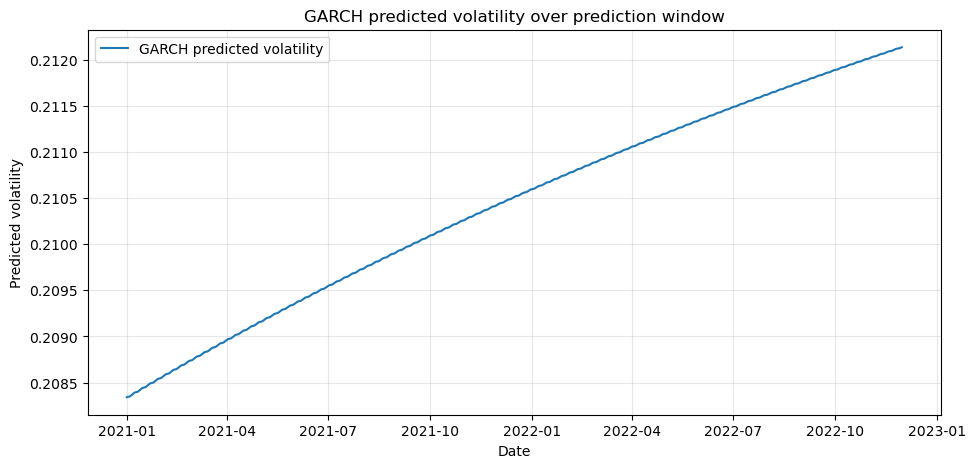

,predicted_volatility
2021-01-01,0.208341
2021-01-04,0.208351
2021-01-05,0.208361
2021-01-06,0.208371
2021-01-07,0.208381


In [8]:
prediction_dates = pd.bdate_range(
    start=pd.to_datetime(split_date),
    end=data.index[-1] + pd.Timedelta(days=1),
)

N = min(len(prediction_dates), len(predicted_volatility))

pred_df = pd.DataFrame({
    "predicted_volatility": predicted_volatility[:N]
}, index=prediction_dates[:N])

plt.figure(figsize=(11, 5))
plt.plot(pred_df.index, pred_df["predicted_volatility"], label="GARCH predicted volatility")
plt.title("GARCH predicted volatility over prediction window")
plt.xlabel("Date")
plt.ylabel("Predicted volatility")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

pred_df.head()

## 9. Simple diagnostic comparison

For a quick check, we compare predicted volatility with realized absolute log returns.

This is not the final group evaluation. It is only a sanity check for `garch_model.py`.

In [9]:
close = data[("Close", ticker)]
returns = np.log(close / close.shift(1)).dropna()
realized_abs_return = returns.loc[returns.index >= split_date].abs()

N = min(len(pred_df), len(realized_abs_return))

diagnostic_df = pd.DataFrame({
    "garch_predicted_volatility": pred_df["predicted_volatility"].iloc[:N].values,
    "realized_abs_return": realized_abs_return.iloc[:N].values,
}, index=realized_abs_return.index[:N])

diagnostic_df.head()

,garch_predicted_volatility,realized_abs_return
2021-01-01,0.208341,0.016089
2021-01-04,0.208351,0.002469
2021-01-05,0.208361,0.010416
2021-01-06,0.208371,0.022019
2021-01-07,0.208381,0.000552


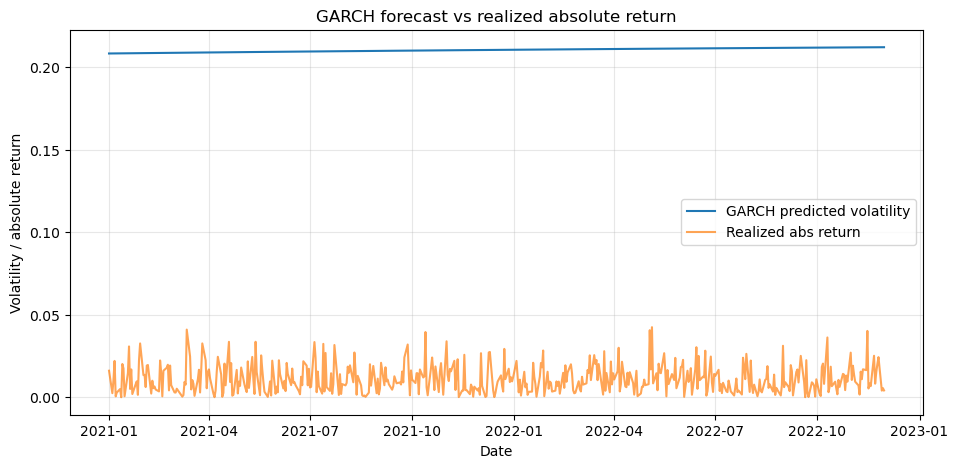

In [10]:
plt.figure(figsize=(11, 5))
plt.plot(diagnostic_df.index, diagnostic_df["garch_predicted_volatility"], label="GARCH predicted volatility")
plt.plot(diagnostic_df.index, diagnostic_df["realized_abs_return"], label="Realized abs return", alpha=0.7)
plt.title("GARCH forecast vs realized absolute return")
plt.xlabel("Date")
plt.ylabel("Volatility / absolute return")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 10. Diagnostic metrics

The metrics below are only for checking this standalone notebook.

The final project should use the group's common `compare_models` code.

In [11]:
y_pred = diagnostic_df["garch_predicted_volatility"].to_numpy()
y_true = diagnostic_df["realized_abs_return"].to_numpy()

error = y_pred - y_true

mse = np.mean(error ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(error))
mape = np.mean(np.abs(error) / np.maximum(np.abs(y_true), 1e-8)) * 100

metrics_df = pd.DataFrame({
    "metric": ["MSE", "RMSE", "MAE", "MAPE"],
    "value": [mse, rmse, mae, mape],
})

metrics_df

,metric,value
0,MSE,0.039772
1,RMSE,0.199429
2,MAE,0.199243
3,MAPE,"10,513.329884"


## 11. Summary

This notebook verifies that `garch_model.py` works independently.

Main output for the group pipeline:

```python
predicted_volatility = fits.test()
```

This output can be passed into the group's model comparison code.